In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    hinge_loss
)

In [2]:
# Load dataset

df = pd.read_csv("cardio_train.csv", sep=';')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
# Data preprocessing

# Drop ID column
df = df.drop(columns=['id'])

# Convert age to years
df['age'] = df['age'] / 365

# Remove outliers
df = df[(df['ap_hi'] < 200) & (df['ap_lo'] < 120)]
df = df[(df['height'] > 120) & (df['weight'] > 40)]

print("Cleaned Shape:", df.shape)

Cleaned Shape: (68434, 12)


In [4]:
# Define features and target

X = df.drop('cardio', axis=1)
y = df['cardio']

In [5]:
# Split into Train (60%), Validation (20%), Test (20%)

# First split: Train (60%) + Temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# Second split: Validation (20%) + Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (41060, 11)
Validation size: (13687, 11)
Test size: (13687, 11)


In [6]:
# Feature scaling 

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [7]:
# Tune hyperparameters using validation set

C_values = [0.01, 0.1, 0.5, 1, 2]
gamma_values = [0.001, 0.01]

best_acc = 0
best_params = {}

for c in C_values:
    for g in gamma_values:
        model = SVC(C=c, gamma=g, kernel='rbf', probability=True)
        model.fit(X_train, y_train)
        
        val_pred = model.predict(X_val)
        acc = accuracy_score(y_val, val_pred)
        
        if acc > best_acc:
            best_acc = acc
            best_params = {'C': c, 'gamma': g}

print("Best Params:", best_params)
print("Validation Accuracy:", best_acc)

Best Params: {'C': 1, 'gamma': 0.01}
Validation Accuracy: 0.7325929714327464


In [8]:
# Train final model using best parameters

best_svm = SVC(
    C=best_params['C'],
    gamma=best_params['gamma'],
    kernel='rbf',
    probability=True
)

best_svm.fit(X_train, y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,0.01
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [9]:
# Evaluate on TEST set (final evaluation)

y_pred = best_svm.predict(X_test)
y_prob = best_svm.predict_proba(X_test)[:, 1]

In [10]:
# Final performance evaluation

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Test Accuracy:", acc)
print("AUC Score:", auc)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.7331044056403887
AUC Score: 0.7933672303497894

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.80      0.75      6940
           1       0.77      0.66      0.71      6747

    accuracy                           0.73     13687
   macro avg       0.74      0.73      0.73     13687
weighted avg       0.74      0.73      0.73     13687



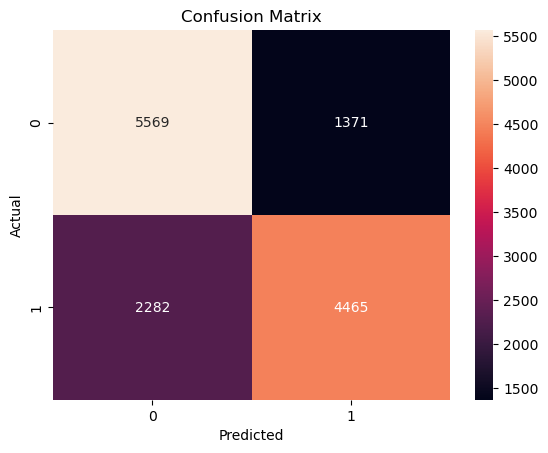

In [11]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

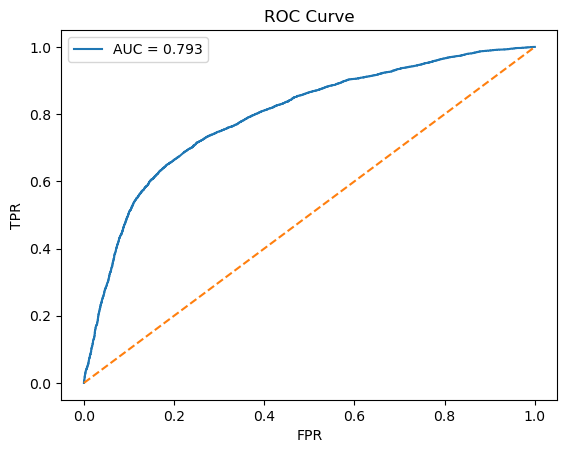

In [12]:
# ROC curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

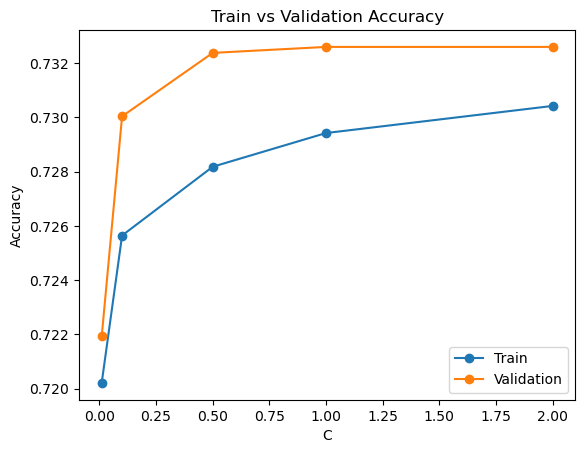

In [13]:
# Accuracy curve

train_acc = []
val_acc = []

for c in C_values:
    model = SVC(C=c, gamma=0.01)
    model.fit(X_train, y_train)
    
    train_acc.append(model.score(X_train, y_train))
    val_acc.append(model.score(X_val, y_val))

plt.figure()
plt.plot(C_values, train_acc, marker='o', label='Train')
plt.plot(C_values, val_acc, marker='o', label='Validation')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.show()

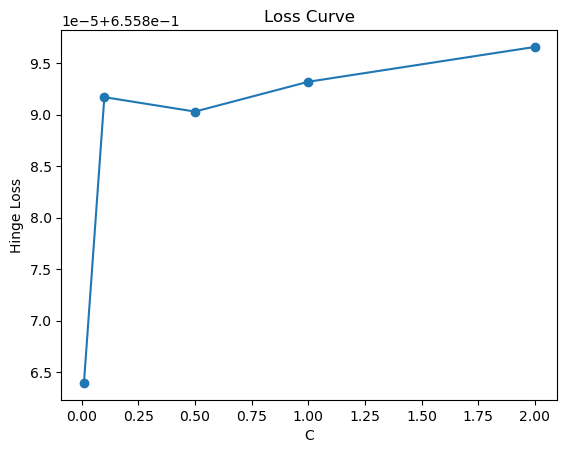

In [14]:
# Loss curve (hinge loss)

loss_values = []

for c in C_values:
    model = SVC(C=c, kernel='linear')
    model.fit(X_train, y_train)
    
    decision = model.decision_function(X_val)
    loss = hinge_loss(y_val, decision)
    loss_values.append(loss)

plt.figure()
plt.plot(C_values, loss_values, marker='o')
plt.xlabel("C")
plt.ylabel("Hinge Loss")
plt.title("Loss Curve")
plt.show()

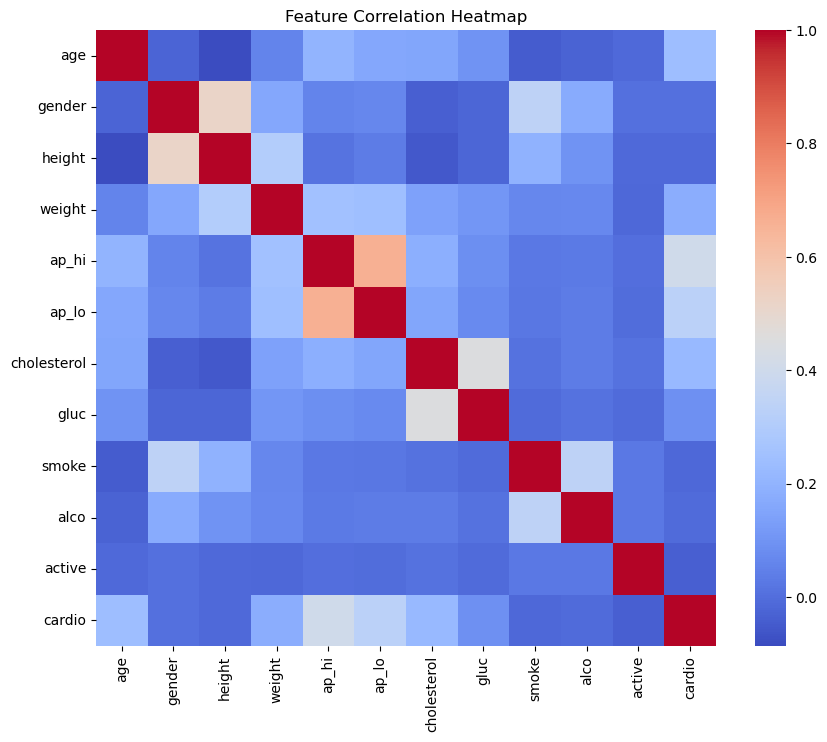

In [15]:
# Feature correlation heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [16]:
# Save model and scaler

joblib.dump(best_svm, "best_svm_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")

Model saved successfully!


In [17]:
# Load model and test prediction

model = joblib.load("best_svm_model.pkl")

sample = X_test[0].reshape(1, -1)
print("Prediction:", model.predict(sample))

Prediction: [0]
